In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# -------------------------------------------------------------
# 1.1 INGESTION
# -------------------------------------------------------------
# Use ISO-8859-1 encoding to correctly handle international characters
try:
    df_raw = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
except FileNotFoundError:
    print("Oops! Double check your folder name and path. Is it definitely 'customer_set/online_retail.csv'?")

print("--- INITIAL DATA PREVIEW ---")
print(df_raw.head())
print("\n--- DATA SHAPE & COLUMNS ---")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")

# -------------------------------------------------------------
# 1.2 DATA CLEANING & QUALITY CONTROL
# -------------------------------------------------------------
df = df_raw.copy()

# 1. Check for missing values
print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())

# Drop rows missing CustomerID to ensure precise customer-level tracking
# We must drop rows where CustomerID is missing.
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int) # Convert float IDs to clean integers

# 2. Convert Data Types
# Convert InvoiceDate to a true pandas datetime object for time-series operations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Handle Business Anomalies (Cancellations & Freebies)
# In this dataset, negative Quantities indicate cancelled orders (Invoices starting with 'C').
# Let's count them, but filter them out for our baseline spending profiles.
cancelled_orders = df[df['Quantity'] < 0].shape[0]
print(f"\nIdentified {cancelled_orders} cancelled transactions/returns.")

# Keep only positive quantities and prices greater than zero
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 4. Feature Engineering (Creating Total Revenue per line)
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

print("\n--- CLEANING COMPLETE ---")
print(f"Remaining Rows: {df.shape[0]}")
print(df.info())

--- INITIAL DATA PREVIEW ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

--- DATA SHAPE & COLUMNS ---
Rows: 541909, Columns: 8

--- MISSING VALUES BEFORE CLEANING ---
InvoiceNo           0
StockCode           0
Description    

--- PHASE 2: EXECUTING BUSINESS INSIGHTS ---

--- TOP 5 COUNTRIES BY REVENUE ---
United Kingdom: £7,308,391.55
Netherlands: £285,446.34
EIRE: £265,545.90
Germany: £228,867.14
France: £209,024.05

--- TOP 5 SELLING PRODUCTS BY VOLUME ---
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
Name: Quantity, dtype: int64


C:\Users\akhil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\akhil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


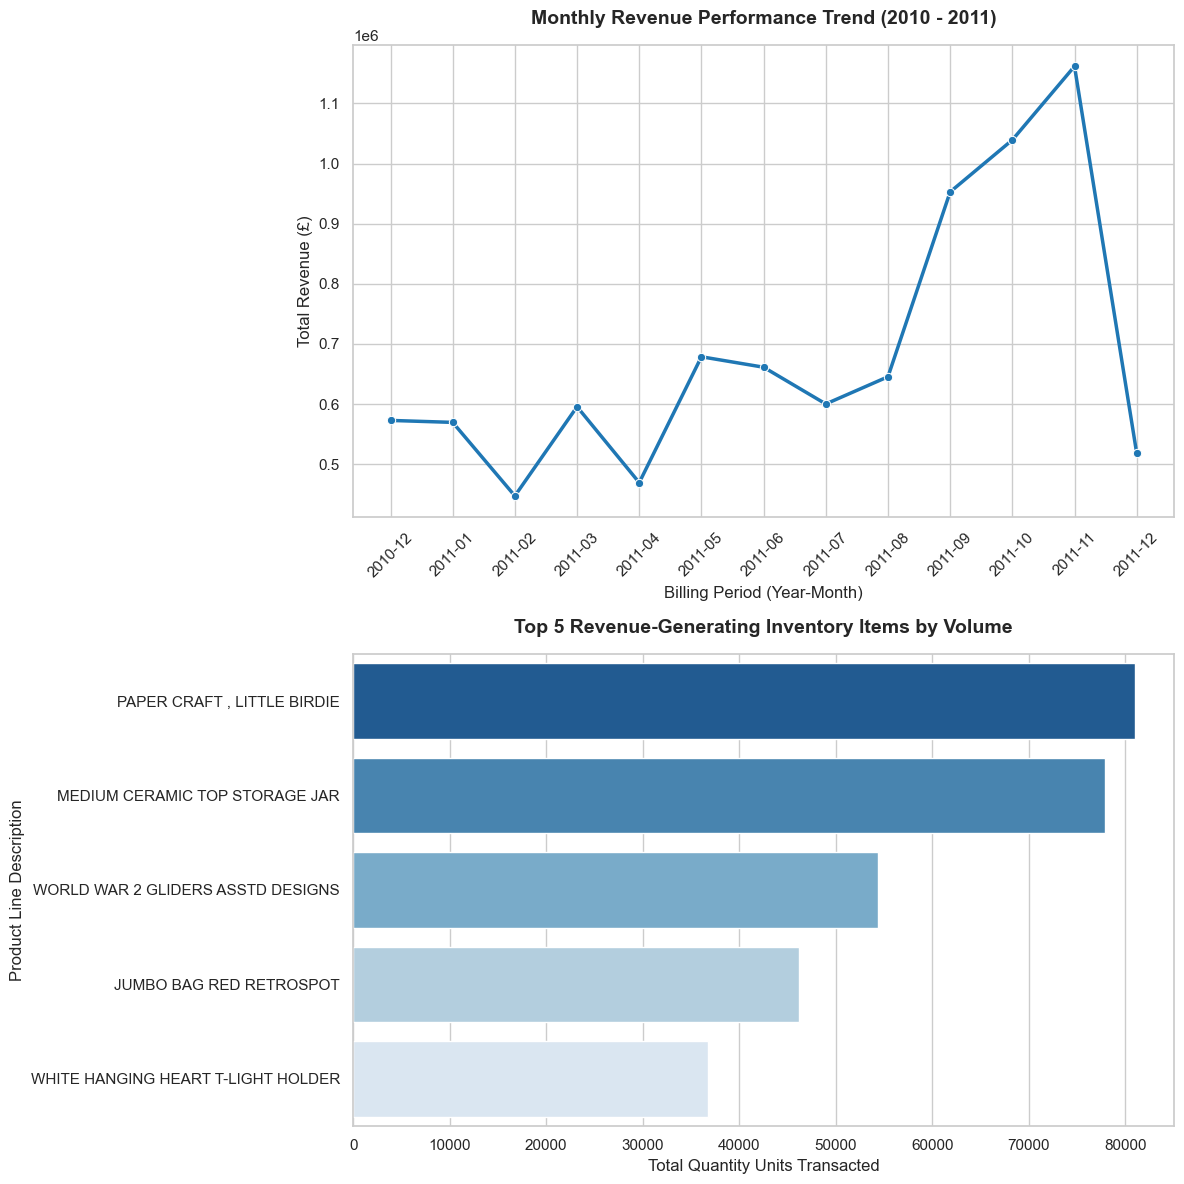

In [3]:
# -------------------------------------------------------------
# 1.EXPLORATORY DATA ANALYSIS (EDA)
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- PHASE 2: EXECUTING BUSINESS INSIGHTS ---")

# 1. Top Countries by Total Revenue
country_revenue = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
print("\n--- TOP 5 COUNTRIES BY REVENUE ---")
for country, rev in country_revenue.items():
    print(f"{country}: £{rev:,.2f}") # Using £ since this is a UK dataset

# 2. Top Selling Products (By Quantity Sold)
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
print("\n--- TOP 5 SELLING PRODUCTS BY VOLUME ---")
print(top_products)

# 3. Monthly Revenue Trend Calculations
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('InvoiceYearMonth')['TotalRevenue'].sum().reset_index()
monthly_rev['InvoiceYearMonth'] = monthly_rev['InvoiceYearMonth'].astype(str)

# -------------------------------------------------------------
# VISUALIZATIONS
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: Monthly Revenue Trend Line
sns.lineplot(
    data=monthly_rev, 
    x='InvoiceYearMonth', 
    y='TotalRevenue', 
    marker='o', 
    color='#1f77b4', 
    linewidth=2.5, 
    ax=axes[0]
)
axes[0].set_title('Monthly Revenue Performance Trend (2010 - 2011)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Billing Period (Year-Month)', fontsize=12)
axes[0].set_ylabel('Total Revenue (£)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Top 5 Best Selling Products
sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    palette='Blues_r', 
    ax=axes[1]
)
axes[1].set_title('Top 5 Revenue-Generating Inventory Items by Volume', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Quantity Units Transacted', fontsize=12)
axes[1].set_ylabel('Product Line Description', fontsize=12)

plt.tight_layout()
plt.show()

--- PHASE 3: COMPUTING CUSTOMER RFM METRICS ---
Dataset snapshot baseline reference date: 2011-12-10
Aggregated data into 4338 unique customer profiles.

--- RFM METRICS SUMMARY PREVIEW ---
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

--- CUSTOMER SEGMENTATION BREAKDOWN ---
Business_Segment
Standard / Occasional Buyers    2219
At Risk / Churn Risk            1084
Champions / Core Loyalists       559
High Spend Whales                476
Name: count, dtype: int64


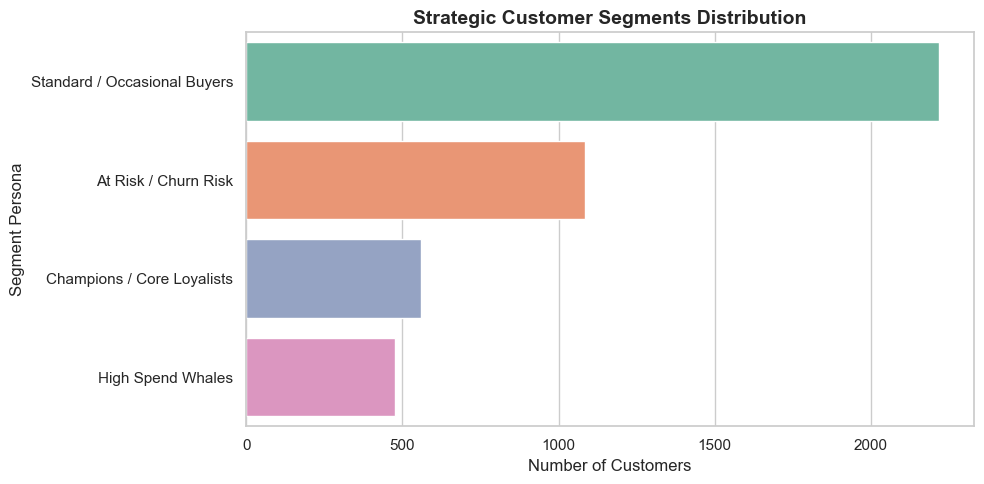

In [5]:
# -------------------------------------------------------------
# 2. CUSTOMER SEGMENTATION (RFM ANALYSIS)
# -------------------------------------------------------------
import datetime as dt

print("--- COMPUTING CUSTOMER RFM METRICS ---")

# To compute Recency, we need a reference point. 
# We'll pretend we are analyzing this data exactly one day after the final invoice recorded.
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Dataset snapshot baseline reference date: {snapshot_date.date()}")

# Aggregate transactional data to the individual customer level
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last order
    'InvoiceNo': 'nunique',                                 # Frequency: Total unique orders
    'TotalRevenue': 'sum'                                   # Monetary: Total spend
}).reset_index()

# Rename columns for clarity
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"Aggregated data into {rfm.shape[0]} unique customer profiles.")
print("\n--- RFM METRICS SUMMARY PREVIEW ---")
print(rfm.head())

# -------------------------------------------------------------
# 3.2 STRATEGIC BUSINESS SEGMENTATION (QUANTILES)
# -------------------------------------------------------------
# Group customers into 1-4 tiers using quartiles
# For Recency: Lower is better (1 = highly active/recent, 4 = inactive for a long time)
rfm['R_Tier'] = pd.qcut(rfm['Recency'], q=4, labels=[1, 2, 3, 4])

# For Frequency & Monetary: Higher is better (1 = high value, 4 = low value)
# We use duplicates='drop' because frequency values can highly overlap at low numbers
rfm['F_Tier'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[4, 3, 2, 1])
rfm['M_Tier'] = pd.qcut(rfm['Monetary'], q=4, labels=[4, 3, 2, 1])

# Define a high-level segment mapping based on metrics
def segment_customer(row):
    # Top tier across the board = Champions
    if row['R_Tier'] == 1 and row['M_Tier'] == 1:
        return 'Champions / Core Loyalists'
    # Low recency tier = At Risk / Slipping Away
    elif row['R_Tier'] == 4:
        return 'At Risk / Churn Risk'
    # High spending but not super recent
    elif row['M_Tier'] == 1:
        return 'High Spend Whales'
    else:
        return 'Standard / Occasional Buyers'

rfm['Business_Segment'] = rfm.apply(segment_customer, axis=1)

# Count and visualize segments
segment_counts = rfm['Business_Segment'].value_counts()
print("\n--- CUSTOMER SEGMENTATION BREAKDOWN ---")
print(segment_counts)

# Plot the customer segmentation distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Set2')
plt.title('Strategic Customer Segments Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Segment Persona', fontsize=12)
plt.tight_layout()
plt.show()

--- PHASE 4: RUNNING UNSUPERVISED MACHINE LEARNING ---

--- MACHINE LEARNING CLUSTER PROFILES (MEANS) ---
            Recency  Frequency     Monetary
Cluster                                    
0         17.027308  13.349805  7908.954083
1        167.361111   1.352030   362.537613
2         44.212728   3.379493  1267.384681


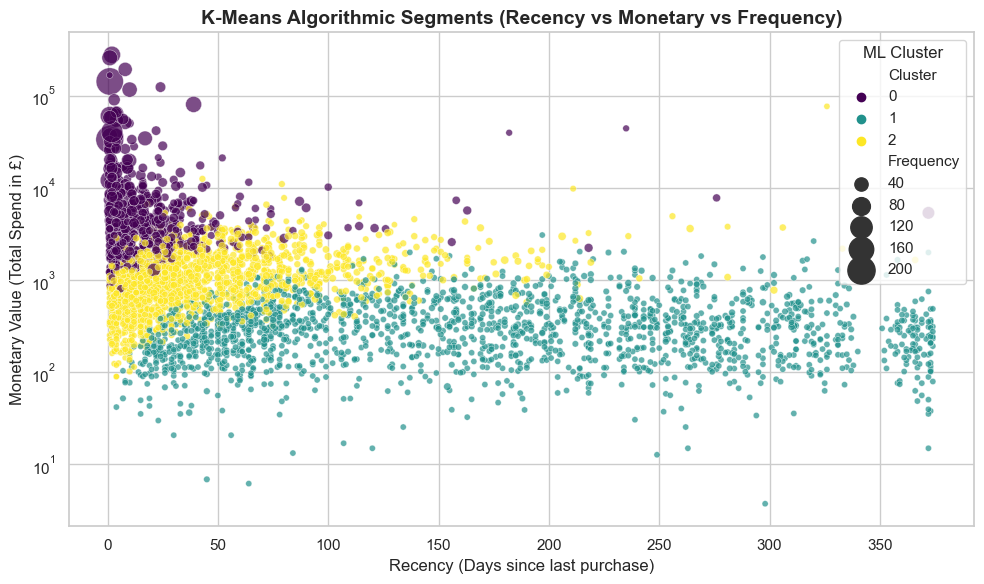

In [7]:
# -------------------------------------------------------------
# 3. MACHINE LEARNING & ADVANCED CLUSTERING
# -------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("--- RUNNING UNSUPERVISED MACHINE LEARNING ---")

# 4.1 Log Transformation to Handle Skewness (Fixes long tails in Monetary/Frequency)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# 4.2 Feature Scaling (Normalizing data to mean=0, variance=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 4.3 Fit K-Means Clustering
# We'll choose 3 clusters to segment into distinct performance tiers (Low, Medium, High Value)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4.4 Profile the Algorithmic Clusters
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("\n--- MACHINE LEARNING CLUSTER PROFILES (MEANS) ---")
print(cluster_profile)

# -------------------------------------------------------------
# VISUALIZATION: 3D-like Scatter Plot of Segments
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.7, 
    size='Frequency', 
    sizes=(20, 400)
)
plt.title('K-Means Algorithmic Segments (Recency vs Monetary vs Frequency)', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Days since last purchase)', fontsize=12)
plt.ylabel('Monetary Value (Total Spend in £)', fontsize=12)
plt.yscale('log') # Use log scale to cleanly see the massive spend gap
plt.legend(title='ML Cluster')
plt.tight_layout()
plt.show()

# Executive Insights Report: E-Commerce Customer Dynamics & Value Segmentation
**Prepared by:** Data Analyst Portfolio Project  
**Data Scope:** UK-Based Retail Transactions (4,338 Unique Customer Profiles Analyzed)

---

## 1. Executive Summary
An analysis of transaction-level retail data was conducted to transition raw purchasing events into structured, individual customer behavior profiles. Utilizing empirical data aggregation and Unsupervised Machine Learning (K-Means Clustering), the customer base was classified into distinct macro-segments. The objective is to provide the marketing and operations teams with data-driven targets to optimize retention and maximize customer lifetime value (CLV).

---

## 2. Key Exploratory & Revenue Insights
* **Geographic Concentration:** The retail operations are heavily centralized, with the **United Kingdom** serving as the primary revenue driver, contributing **£7,308,391.55**. International expansion opportunities exist in high-performing secondary European markets including the Netherlands (£285.4k), EIRE (£265.5k), and Germany (£228.8k).
* **Inventory Demand Drivers:** Inventory lines such as "PAPER CRAFT, LITTLE BIRDIE" and "MEDIUM CERAMIC TOP STORAGE JAR" represent massive single-point volume drivers. Supply chains must prioritize high-efficiency storage and distribution logistics for these items to avoid stockouts.

---

## 3. Algorithmic Customer Segmentation (K-Means)
The optimal mathematical clustering identified three definitive tiers of customers:

| Customer Persona | Recency (Avg) | Frequency (Avg Orders) | Monetary Spend (Avg) | Strategic Business Action |
| :--- | :--- | :--- | :--- | :--- |
| **Cluster 0: High-Value VIPs** | 17 Days | 13.3 Orders | £7,908.95 | **Protect & Reward:** Enroll in exclusive VIP programs, early product access, and dedicated account treatment. |
| **Cluster 2: Steady Core Buyers** | 44 Days | 3.4 Orders | £1,267.38 | **Upsell & Cross-sell:** Introduce personalized product bundles and trigger-based email recommendations to drive order frequency. |
| **Cluster 1: Dormant / At-Risk** | 167 Days | 1.3 Orders | £362.54 | **Win-Back Campaigns:** Deploy high-incentive promotional discounts or feedback surveys to address friction before permanent churn. |

---

## 4. Strategic Recommendations
1. **Targeted Re-Engagement:** Reallocate marketing spend from broad awareness to targeted win-back campaigns focusing explicitly on Cluster 1 customers who have been inactive for over 150 days.
2. **VIP Loyalty Lock-in:** Given that Cluster 0 accounts for a massive share of total profitability despite a smaller customer count, prioritize customer satisfaction and loyalty infrastructure for this segment to minimize high-value attrition.